In [1]:

import sys
import pickle
import random
import os
script_path = os.path.abspath("../../Library/python/cebra_analysis_helpers")
if script_path not in sys.path:
    sys.path.append(script_path)
import cebra_analysis_helpers
import pandas as pd
import seaborn as sns
from scipy.stats import wilcoxon


In [2]:
# create the ice fire cmap for matplotlib
import plotly.express as px
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
def plotly_to_matplotlib_cmap(plotly_cmap_name, samples=500):
    """Converts a Plotly colormap to a Matplotlib ListedColormap."""
    plotly_cmap = px.colors.sample_colorscale(plotly_cmap_name, samples)
    rgb_colors = [(int(c[4:].split(',')[0])/255, int(c.split(',')[1])/255, int(c.split(',')[2].replace(')',''))/255) for c in plotly_cmap]
    matplotlib_cmap = mcolors.ListedColormap(rgb_colors, name=plotly_cmap_name, N=samples)
    return matplotlib_cmap
# Convert 'icefire' colormap
icefire_cmap = plotly_to_matplotlib_cmap('icefire')

The code below gets the CEBRA neural population embeddings for each time point for the train and validation set of data for CEBRA-behavior under actual and shifted behavioral variables of partner distance and egocentric angle. We plot these 3D embeddings and color the plots by the behavioral variable to see how well the variable provides separation in the embeddings in actual versus shifted control.

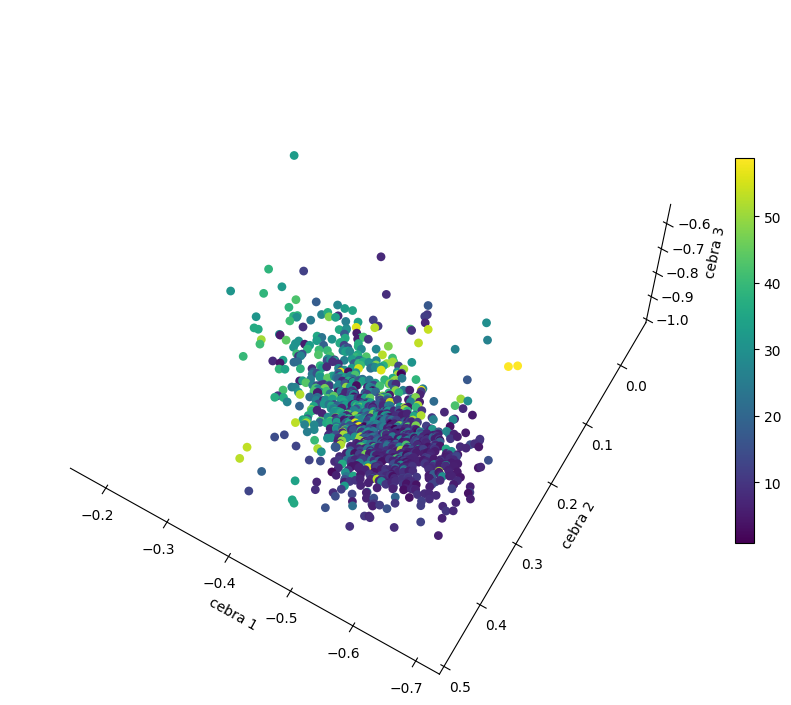

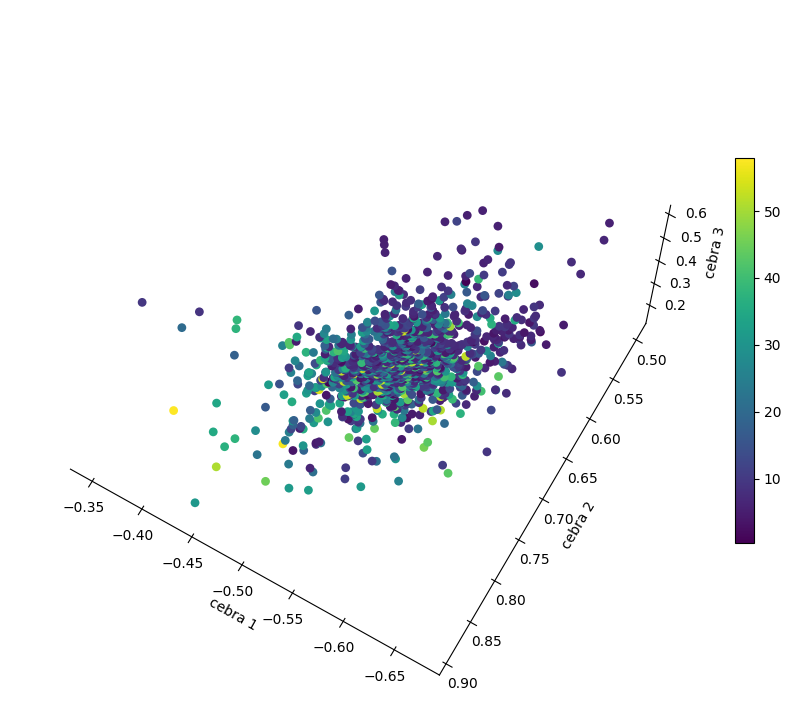

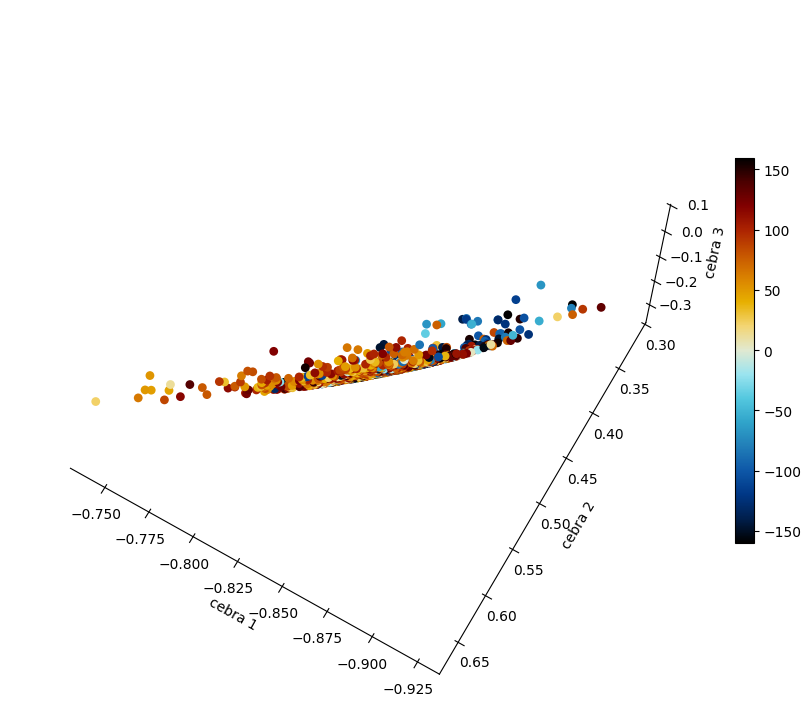

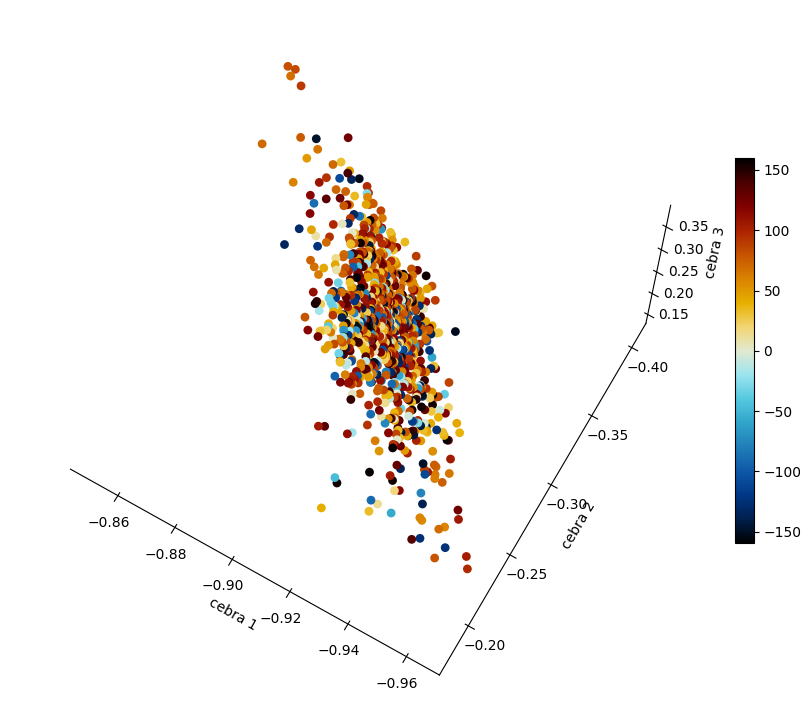

In [3]:
# choose a representative subject to plot
id = 73
m_str = f"YC0{id}"
# select the CEBRA parameters which render the best separation
tmp = 0.01
m_iter = 1000
test_size = 0.2
num_parallel= 100
num_clusters = 5
counter = 0
# choose plotting parameters
s = 40
alpha = 1
roll = 0
demo = True
model_path_init = f"../../data/gridsearch_results/demo_YC0{id}_bs500_tmp{tmp}_Miter{m_iter}_h32_lr3e-4/"
data_dict_path_init = f"../../data/gridsearch_results/demo_YC0{id}_bs500_tmp{tmp}_Miter{m_iter}_h32_lr3e-4/"
# set up a list with the titles we want to use at each place in the for loop
titles = ["partner distance", "shifted distance", "egocentric partner angle", "shifted angle"]
# for each behavioral variable
for behav_str in ["distance", "angle"]:
    # for whether or not we will shift the data for our control or use the actual data
    for shift_str in ["","+shift0.5"]:
        this_plot_title = titles[counter]
        cmap = "viridis" if "distance" in behav_str else icefire_cmap            
        model_path = f"{model_path_init}{behav_str}_noRZ_ITI+T_ByT{shift_str}_{id}/multi_cebra_model_{id}.pkl"
        data_dict_path = f"{data_dict_path_init}{behav_str}_noRZ_ITI+T_ByT{shift_str}_{id}/train_valid_dict_{id}.pkl"
        behavior = data_dict_path.split("/")[-2][:20]
        approach = data_dict_path.split("/")[-2].split("noRZ")[1]
        temperature =  data_dict_path.split("_tmp")[1][:3]
        max_iter = data_dict_path.split("_Miter")[1][:6]
        num_hidden_units = data_dict_path.split("_h")[1][:3]
        lr = data_dict_path.split("_lr")[1][:3]
        batch_size = data_dict_path.split("_bs")[1][:4]
        behav_label = "egocentric partner angle" if "ego" in behavior else "egocentric partner distance"
        load_file = data_dict_path
        with open(load_file, 'rb') as f:
            train_valid_dict =  pickle.load(f)

        train_multi_embeddings = train_valid_dict["train_multi_embeddings"]
        valid_multi_embeddings = train_valid_dict["valid_multi_embeddings"]
        train_indices_list = train_valid_dict["train_indices_list"]
        valid_indices_list = train_valid_dict["valid_indices_list"]
        cropped_indices_of_trials_each_frame_list = train_valid_dict["cropped_indices_of_trials_each_frame_list"]
        behavior_labels_behavior_mode_list = train_valid_dict["behavior_labels_behavior_mode_list"]
        neural_data_behavior_mode_list = train_valid_dict["neural_data_behavior_mode_list"]
        behavior = train_valid_dict["behavior"]
        approach = train_valid_dict["approach"]
        train_cropped_indices_of_trials_each_frame_list = \
            [cropped_indices[train_indices] for train_indices,cropped_indices in zip(train_indices_list, cropped_indices_of_trials_each_frame_list)]
        valid_cropped_indices_of_trials_each_frame_list = \
            [cropped_indices[valid_indices] for valid_indices,cropped_indices in zip(valid_indices_list, cropped_indices_of_trials_each_frame_list)]

        train_behavior_labels_behavior_mode_list = \
            [behavior_labels[train_indices] for train_indices,behavior_labels in zip(train_indices_list, behavior_labels_behavior_mode_list)]
        valid_behavior_labels_behavior_mode_list = \
            [behavior_labels[valid_indices] for valid_indices,behavior_labels in zip(valid_indices_list, behavior_labels_behavior_mode_list)]

        train_neural_data_behavior_mode_list = \
            [this_neural_data[train_indices] for train_indices,this_neural_data in zip(train_indices_list, neural_data_behavior_mode_list)]
        valid_neural_data_behavior_mode_list = \
            [this_neural_data[valid_indices] for valid_indices,this_neural_data in zip(valid_indices_list, neural_data_behavior_mode_list)]


        dataset_type = "valid"
        cmin = 0 if "self_other_distance" in behavior else None
        cmax = 35 if "self_other_distance" in behavior else None
        x_all = np.hstack([valid_multi_embeddings[i][:,0] for i in range(len(valid_multi_embeddings))])
        y_all = np.hstack([valid_multi_embeddings[i][:,1] for i in range(len(valid_multi_embeddings))])
        z_all = np.hstack([valid_multi_embeddings[i][:,2] for i in range(len(valid_multi_embeddings))])
        valid_behavior_labels_behavior_mode_all = np.hstack([valid_behavior_labels_behavior_mode_list[i][:] for i in range (len(valid_behavior_labels_behavior_mode_list))])
        random_indices = random.sample([i for i in range(len(x_all))], k = int(len(x_all) * 0.05))
        view_init = (70,120)
        cebra_analysis_helpers.plot3D_color_map_matplotlib(x = x_all[random_indices].tolist(), y = y_all[random_indices].tolist(), z = z_all[random_indices].tolist(), colors = valid_behavior_labels_behavior_mode_all[random_indices].tolist(),
                       view_init = view_init, roll = roll, cmap = cmap, title = this_plot_title, cbar_title="", save_fig=True, vmin = cmin, vmax = cmax, s = s,alpha = alpha)
        counter += 1

Get the silhouette scores for these 4 plots for 7 of the animals (above we just plot one representative animal)

In [4]:
tmp = 0.01
m_iter = 1000
test_size = 0.2
num_parallel= 400
num_clusters = 5
mouse_folder_list = ["YC073"]
is_odd_list = [True,False,True,False,True,False,True,False]
is_follower_list = [True,False,True,False,True,False,True,False]
is_leader_list = [not x for x in is_follower_list]
distance_actual_sils = []
distance_shift_sils = []
angle_actual_sils = []
id = 73
angle_shift_sils = []

model_path_init = f"../../data/gridsearch_results/demo_YC0{id}_bs500_tmp{tmp}_Miter{m_iter}_h32_lr3e-4/"
data_dict_path_init = f"../../data/gridsearch_results/demo_YC0{id}_bs500_tmp{tmp}_Miter{m_iter}_h32_lr3e-4/"
for behav_str in ["distance", "angle"]:
    actual_sils = []
    shift_sils = []
    for shift_str in ["","+shift0.5"]:
        for is_leader, id in zip(is_leader_list,[i for i in range(73,74)]):
            m_str = f"YC0{id}"
            model_path = f"{model_path_init}{behav_str}_noRZ_ITI+T_ByT{shift_str}_{id}/multi_cebra_model_{id}.pkl"
            data_dict_path = f"{data_dict_path_init}{behav_str}_noRZ_ITI+T_ByT{shift_str}_{id}/train_valid_dict_{id}.pkl"
            behavior = data_dict_path.split("/")[-2][:20]
            approach = data_dict_path.split("/")[-2].split("noRZ")[1] 
            temperature =  data_dict_path.split("_tmp")[1][:3]
            max_iter = data_dict_path.split("_Miter")[1][:6]
            num_hidden_units = data_dict_path.split("_h")[1][:3]
            lr = data_dict_path.split("_lr")[1][:3]
            batch_size = data_dict_path.split("_bs")[1][:4]
            behav_label = "egocentric partner angle" if "ego" in behavior else "egocentric partner distance"
            load_file = data_dict_path
            with open(load_file, 'rb') as f:
                train_valid_dict =  pickle.load(f)
            train_multi_embeddings = train_valid_dict["train_multi_embeddings"]
            valid_multi_embeddings = train_valid_dict["valid_multi_embeddings"]
            train_indices_list = train_valid_dict["train_indices_list"]
            valid_indices_list = train_valid_dict["valid_indices_list"]
            cropped_indices_of_trials_each_frame_list = train_valid_dict["cropped_indices_of_trials_each_frame_list"]
            behavior_labels_behavior_mode_list = train_valid_dict["behavior_labels_behavior_mode_list"]
            neural_data_behavior_mode_list = train_valid_dict["neural_data_behavior_mode_list"]
            behavior = train_valid_dict["behavior"]
            approach = train_valid_dict["approach"]
            train_cropped_indices_of_trials_each_frame_list = \
                [cropped_indices[train_indices] for train_indices,cropped_indices in zip(train_indices_list, cropped_indices_of_trials_each_frame_list)]
            valid_cropped_indices_of_trials_each_frame_list = \
                [cropped_indices[valid_indices] for valid_indices,cropped_indices in zip(valid_indices_list, cropped_indices_of_trials_each_frame_list)]

            train_behavior_labels_behavior_mode_list = \
                [behavior_labels[train_indices] for train_indices,behavior_labels in zip(train_indices_list, behavior_labels_behavior_mode_list)]
            valid_behavior_labels_behavior_mode_list = \
                [behavior_labels[valid_indices] for valid_indices,behavior_labels in zip(valid_indices_list, behavior_labels_behavior_mode_list)]

            train_neural_data_behavior_mode_list = \
                [this_neural_data[train_indices] for train_indices,this_neural_data in zip(train_indices_list, neural_data_behavior_mode_list)]
            valid_neural_data_behavior_mode_list = \
                [this_neural_data[valid_indices] for valid_indices,this_neural_data in zip(valid_indices_list, neural_data_behavior_mode_list)]

            # valid
            dataset_type = "valid"
            x_all = np.hstack([valid_multi_embeddings[i][:,0] for i in range(len(valid_multi_embeddings))])
            y_all = np.hstack([valid_multi_embeddings[i][:,1] for i in range(len(valid_multi_embeddings))])
            z_all = np.hstack([valid_multi_embeddings[i][:,2] for i in range(len(valid_multi_embeddings))])
            valid_behavior_labels_behavior_mode_all = np.hstack([valid_behavior_labels_behavior_mode_list[i][:] for i in range (len(valid_behavior_labels_behavior_mode_list))])
            # all together
            sil_scores = cebra_analysis_helpers.get_silhouette_scores(x_all, y_all, z_all,valid_behavior_labels_behavior_mode_all, num_clusters= num_clusters, num_parallel= num_parallel)
            if "shift" in shift_str:
                shift_sils.append(np.mean(sil_scores))
            else:
                actual_sils.append(np.mean(sil_scores))
    print(wilcoxon(x = actual_sils, y = shift_sils))
    if "distance" in behav_str:
        distance_plot_dict = {"behavior label": ["partner distance" for i in range(len(actual_sils))] + ["shifted distance" for i in range(len(actual_sils))],
                     "modified silhouette score": actual_sils + shift_sils}
        sns.stripplot(data=pd.DataFrame(distance_plot_dict), x="behavior label", y="modified silhouette score")
        plt.savefig(f"tmp_figures/{behav_str}_{shift_str}_sils.pdf", transparent=True, format = "pdf", bbox_inches = "tight")
        plt.show()
    else:
        angle_plot_dict = {"behavior label": ["egocentric partner angle" for i in range(len(actual_sils))] + ["shifted angle" for i in range(len(actual_sils))],
                     "modified silhouette score": actual_sils + shift_sils} 
        sns.stripplot(data=pd.DataFrame(angle_plot_dict), x="behavior label", y="modified silhouette score")
        plt.savefig(f"tmp_figures/{behav_str}_{shift_str}_sils.pdf", transparent=True, format = "pdf", bbox_inches = "tight")
        plt.show()


KeyboardInterrupt: 